In [46]:
import numpy as np
import strawberryfields as sf
from strawberryfields.ops import Dgate, LossChannel, BSgate, Rgate
from dataclasses import dataclass

@dataclass
class COWConfig:
    """MASTER CONTROL PANEL for COW QKD Simulation"""
    
    # --- 1. Channel / Fiber Physics ---
    mean_photon_number_mu: float = 0.5    
    fiber_loss_db_km: float = 0.2         # Standard telecom fiber (0.2 dB/km)
    distance_km: float = 40.0             
    additional_loss_db: float = 0.0       # Tweak for macro-bending or internal optical losses
    
    # --- 2. Hardware / Detector Constraints ---
    t_B: float = 0.90                     # 90:10 Beam Splitter distribution
    efficiency_eta: float = 0.10          # SPAD Quantum Efficiency (10% to 100%)
    dead_time_us: float = 50.0            # Detector blinding time after a click
    dark_count_prob_per_ns: float = 2.5e-5 
    repetition_rate_hz: float = 500e6     # Laser pulse frequency
    visibility_V: float = 0.98            # Hardware phase interference visibility
    
    # --- 3. Sifting / Protocol Rules ---
    # Set to 0.0 if no monitor line is used (all data). Set to 0.5 if 50% are decoys.
    decoy_fraction_f: float = 0.0         
    
    # --- 4. System Inefficiencies (The "Fudge" Factors) ---
    # Jitter/Timing loss. Set to 0.0 for pure theory, or ~0.385 to match Malpani et al.
    filtering_percentage: float = 0.0     
    
    # --- 5. Classical Post-Processing ---
    disclose_rate_DR: float = 0.03125     # Fraction of key sacrificed to check QBER
    compression_ratio_CR: float = 0.50    # Fraction of key sacrificed for Privacy Amplification

class QuantumLayer:
    """
    Handles all Strawberry Fields continuous-variable simulations.
    Calculates the exact quantum probabilities of detector clicks for a single sequence.
    """
    def __init__(self, config: COWConfig):
        self.config = config
        
    def calculate_transmittance(self) -> float:
        """Calculates total channel transmittance (t) based on fiber losses."""
        total_loss_db = (self.config.fiber_loss_db_km * self.config.distance_km) + self.config.additional_loss_db
        return 10 ** (-total_loss_db / 10)

    def simulate_bit_sequence(self, bit_value: int) -> dict:
        """
        Simulates Alice sending either Bit 1 (|alpha>|0>) or Bit 0 (|0>|alpha>).
        Returns the mean photon numbers arriving at Bob's data line.
        """
        t = self.calculate_transmittance()
        alpha = np.sqrt(self.config.mean_photon_number_mu)
        
        # Spatial Mapping:
        # q[0]: Early Bin (Alice)  -> q[2]: Early Bin (Data Line)
        # q[1]: Late Bin (Alice)   -> q[3]: Late Bin (Data Line)
        prog = sf.Program(4)
        theta_BS = np.arccos(np.sqrt(self.config.t_B))
        
        with prog.context as q:
            # 1. State Preparation based on bit value
            if bit_value == 1:
                Dgate(alpha) | q[0]  # Photon in early bin
            elif bit_value == 0:
                Dgate(alpha) | q[1]  # Photon in late bin
            
            # 2. Channel Loss
            LossChannel(t) | q[0]
            LossChannel(t) | q[1]
            
            # 3. Bob's 90:10 Data Split
            BSgate(theta_BS, 0) | (q[0], q[2]) # Early bin splits
            BSgate(theta_BS, 0) | (q[1], q[3]) # Late bin splits

        eng = sf.Engine(backend="gaussian")
        result = eng.run(prog)
        state = result.state
        
        # FIX: Extract actual mean photon numbers <n> for modes 2 and 3
        return {
            "mean_early_data": float(state.mean_photon(2)[0]),
            "mean_late_data": float(state.mean_photon(3)[0])
        }

    def simulate_decoy_interference(self) -> dict:
        """
        Simulates |alpha>|alpha> through the monitor line interferometer.
        Incorporates physical phase drift to match target hardware visibility.
        """
        t = self.calculate_transmittance()
        alpha = np.sqrt(self.config.mean_photon_number_mu)
        
        prog = sf.Program(6)
        theta_9010 = np.arccos(np.sqrt(self.config.t_B))
        theta_5050 = np.pi / 4 
        
        # Calculate the phase error needed to degrade visibility to the config limit
        phase_error = np.arccos(self.config.visibility_V)
        
        with prog.context as q:
            # 1. Alice prepares Decoy
            Dgate(alpha) | q[0]
            Dgate(alpha) | q[1]
            
            # 2. Channel Loss
            LossChannel(t) | q[0]
            LossChannel(t) | q[1]
            
            # 3. Bob's 90:10 Split
            BSgate(theta_9010, 0) | (q[0], q[2])
            BSgate(theta_9010, 0) | (q[1], q[3])
            
            # 4. Interferometer First 50:50 Splitter
            BSgate(theta_5050, 0) | (q[0], q[4]) # Early pulse
            BSgate(theta_5050, 0) | (q[1], q[5]) # Late pulse
            
            # 5. INJECT PHYSICAL IMPERFECTIONS (Phase Drift)
            Rgate(phase_error) | q[1]
            
            # 6. Final Interference 
            BSgate(theta_5050, np.pi) | (q[0], q[1])

        eng = sf.Engine(backend="gaussian")
        result = eng.run(prog)
        state = result.state
        
        # FIX: Extract actual mean photon numbers <n> for detectors D_M1 and D_M2
        mean_DM1 = float(state.mean_photon(0)[0])
        mean_DM2 = float(state.mean_photon(1)[0])
        
        total_photons = mean_DM1 + mean_DM2
        simulated_vis = (mean_DM1 - mean_DM2) / total_photons if total_photons > 0 else 0
        
        return {
            "mean_DM1": mean_DM1,
            "mean_DM2": mean_DM2,
            "simulated_visibility": float(simulated_vis)
        }
    
if __name__ == "__main__":
    config = COWConfig(distance_km=40.0, visibility_V=0.98) 
    quantum = QuantumLayer(config)
    
    print("--- Testing Bit 1 ---")
    res_1 = quantum.simulate_bit_sequence(bit_value=1)
    print(f"Early Window Data Photons: {res_1['mean_early_data']:.6f} | Late Window: {res_1['mean_late_data']:.6f}")
    
    print("\n--- Testing Bit 0 ---")
    res_0 = quantum.simulate_bit_sequence(bit_value=0)
    print(f"Early Window Data Photons: {res_0['mean_early_data']:.6f} | Late Window: {res_0['mean_late_data']:.6f}")
    
    print("\n--- Testing Interferometer (Target Visibility: 98%) ---")
    res_decoy = quantum.simulate_decoy_interference()
    print(f"Photons at D_M1: {res_decoy['mean_DM1']:.6f}")
    print(f"Photons at D_M2: {res_decoy['mean_DM2']:.6f} (Leakage due to phase error)")
    print(f"Simulated Visibility: {res_decoy['simulated_visibility']*100:.2f}%")

--- Testing Bit 1 ---
Early Window Data Photons: 0.007924 | Late Window: 0.000000

--- Testing Bit 0 ---
Early Window Data Photons: 0.000000 | Late Window: 0.007924

--- Testing Interferometer (Target Visibility: 98%) ---
Photons at D_M1: 0.070607
Photons at D_M2: 0.000713 (Leakage due to phase error)
Simulated Visibility: 98.00%


/Users/rahul/Documents/QKD/Codes/cow-qkd-env/lib/python3.11/site-packages/strawberryfields/program.py:732: UserWarning: The circuit consists of 2 disconnected components.


In [55]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
import time

# (Assuming COWConfig and QuantumLayer are already defined)

class ClassicalLayer:
    """
    Handles both macroscopic (statistical) and microscopic (pulse-by-pulse) 
    classical simulations for the COW protocol.
    """
    def __init__(self, config, quantum_layer):
        self.config = config
        self.quantum = quantum_layer

    def _calculate_poisson_click_prob(self, mean_photon_number: float) -> float:
        """Calculates the probability of AT LEAST one photon triggering the SPAD."""
        # FIX: Apply Quantum Efficiency (eta) directly here so the microscopic loop uses it!
        effective_photons = mean_photon_number * self.config.efficiency_eta
        return 1.0 - np.exp(-effective_photons)

    def run_microscopic_simulation(self, n_bits: int = 100000000) -> pd.DataFrame:
        """
        Simulates the protocol pulse-by-pulse, tracking exact timestamps,
        detector dead-times, and specific bit errors.
        """
        # 1. Fetch exact quantum probabilities from the Quantum Layer   
        res_bit_1 = self.quantum.simulate_bit_sequence(bit_value=1)
        res_bit_0 = self.quantum.simulate_bit_sequence(bit_value=0)
        
        # Calculate poisson click probabilities for data line
        # (These now automatically factor in the 10% detector efficiency)
        p_click_1_early = self._calculate_poisson_click_prob(res_bit_1['mean_early_data'])
        p_click_1_late  = self._calculate_poisson_click_prob(res_bit_1['mean_late_data'])
        p_click_0_early = self._calculate_poisson_click_prob(res_bit_0['mean_early_data'])
        p_click_0_late  = self._calculate_poisson_click_prob(res_bit_0['mean_late_data'])

        # Dark count probability per time bin window (2ns for 500MHz)
        bin_duration_s = 1.0 / self.config.repetition_rate_hz
        p_dark_per_bin = self.config.dark_count_prob_per_ns * (bin_duration_s * 1e9)
        
        # Dead time converted to seconds
        dead_time_s = self.config.dead_time_us * 1e-6
        
        # 2. Generate Alice's Random Sequence (0s and 1s)
        alice_bits = np.random.randint(0, 2, size=n_bits)
        
        # Tracking arrays
        detection_log = []
        detector_dead_until_s = 0.0
        
        print(f"Starting microscopic simulation for {n_bits:,} bits...")
        start_time_compute = time.time()
        
        # 3. Pulse-by-Pulse Simulation Loop
        for i in range(n_bits):
            # Calculate time at start of this bit (each bit takes 2 bins)
            bit_start_time_s = i * (2 * bin_duration_s)
            
            # --- EARLY WINDOW CHECK (Represents Bit 1) ---
            early_window_time = bit_start_time_s
            if early_window_time >= detector_dead_until_s:
                p_photon = p_click_1_early if alice_bits[i] == 1 else p_click_0_early
                total_p_click = p_photon + p_dark_per_bin
                
                if np.random.rand() < total_p_click:
                    bob_bit = 1
                    is_error = (bob_bit != alice_bits[i])
                    
                    detection_log.append({
                        "bit_index": i,
                        "timestamp_s": early_window_time,
                        "alice_sent": alice_bits[i],
                        "bob_received": bob_bit,
                        "is_error": is_error,
                        "trigger": "photon" if np.random.rand() < (p_photon / total_p_click) else "dark_count"
                    })
                    detector_dead_until_s = early_window_time + dead_time_s
                    continue 
            
            # --- LATE WINDOW CHECK (Represents Bit 0) ---
            late_window_time = bit_start_time_s + bin_duration_s
            if late_window_time >= detector_dead_until_s:
                p_photon = p_click_1_late if alice_bits[i] == 1 else p_click_0_late
                total_p_click = p_photon + p_dark_per_bin
                
                if np.random.rand() < total_p_click:
                    bob_bit = 0
                    is_error = (bob_bit != alice_bits[i])
                    
                    detection_log.append({
                        "bit_index": i,
                        "timestamp_s": late_window_time,
                        "alice_sent": alice_bits[i],
                        "bob_received": bob_bit,
                        "is_error": is_error,
                        "trigger": "photon" if np.random.rand() < (p_photon / total_p_click) else "dark_count"
                    })
                    detector_dead_until_s = late_window_time + dead_time_s

        print(f"Simulation completed in {time.time() - start_time_compute:.2f} seconds.")
        
        # 4. Compile Results into a DataFrame
        df_results = pd.DataFrame(detection_log)
        return df_results

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    # Use the Master Control Panel directly!
    config = COWConfig(distance_km=40.0)
    
    quantum = QuantumLayer(config)
    classical = ClassicalLayer(config, quantum)
    
    df_detections = classical.run_microscopic_simulation(n_bits=100000000)
    
    total_detections = len(df_detections)
    total_errors = df_detections['is_error'].sum()
    qber = (total_errors / total_detections) * 100 if total_detections > 0 else 0
    
    print("\n--- Microscopic Simulation Results ---")
    print(f"Total Detections Logged: {total_detections}")
    print(f"Total Errors Found: {total_errors}")
    print(f"Simulated QBER: {qber:.2f}%")

Starting microscopic simulation for 100,000,000 bits...
Simulation completed in 15.44 seconds.

--- Microscopic Simulation Results ---
Total Detections Logged: 7340
Total Errors Found: 389
Simulated QBER: 5.30%



--- Processing 40.0 km ---


/Users/rahul/Documents/QKD/Codes/cow-qkd-env/lib/python3.11/site-packages/strawberryfields/program.py:732: UserWarning: The circuit consists of 2 disconnected components.


Starting microscopic simulation for 100,000,000 bits...
Simulation completed in 15.47 seconds.
-> SUCCESS: Saved 7336 physical detection events to 'cow_detections_40km_log.csv'
-> Derived Sifted Key Rate: 18,340 bps

--- Processing 80.0 km ---


/Users/rahul/Documents/QKD/Codes/cow-qkd-env/lib/python3.11/site-packages/strawberryfields/program.py:732: UserWarning: The circuit consists of 2 disconnected components.


Starting microscopic simulation for 100,000,000 bits...
Simulation completed in 30.68 seconds.
-> SUCCESS: Saved 5913 physical detection events to 'cow_detections_80km_log.csv'
-> Derived Sifted Key Rate: 14,782 bps

--- Processing 120.0 km ---


/Users/rahul/Documents/QKD/Codes/cow-qkd-env/lib/python3.11/site-packages/strawberryfields/program.py:732: UserWarning: The circuit consists of 2 disconnected components.


Starting microscopic simulation for 100,000,000 bits...
Simulation completed in 43.33 seconds.
-> SUCCESS: Saved 4795 physical detection events to 'cow_detections_120km_log.csv'
-> Derived Sifted Key Rate: 11,988 bps


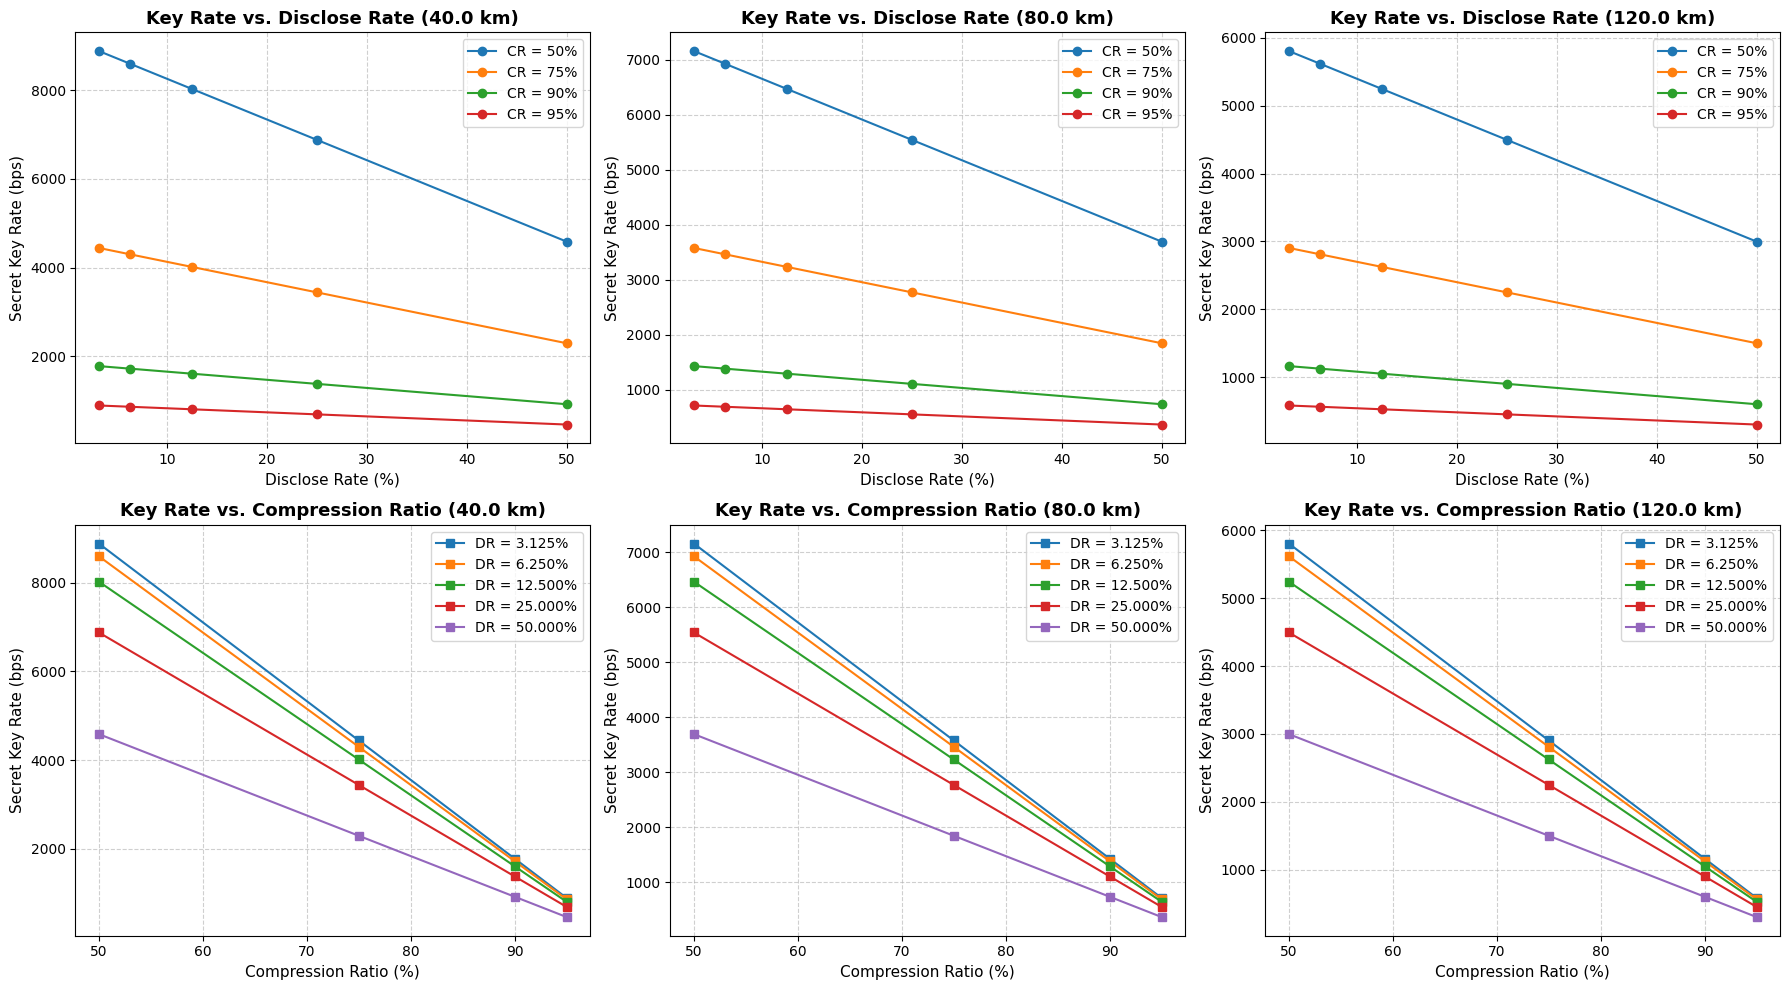

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Prepare our variables
distances = [40.0, 80.0, 120.0]
dr_values = np.array([0.03125, 0.0625, 0.125, 0.25, 0.50])
cr_values = np.array([0.50, 0.75, 0.90, 0.95])
n_bits_simulated = 100000000

# Create the figure grid (2 rows: DR and CR, 3 columns: Distances)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, dist in enumerate(distances):
    print(f"\n=========================================")
    print(f"--- Processing {dist} km ---")
    
    # 2. Update config and re-initialize layers for the new distance
    config.distance_km = dist
    quantum = QuantumLayer(config)
    classical = ClassicalLayer(config, quantum)
    
    # 3. Run Microscopic Tracker
    df_detections = classical.run_microscopic_simulation(n_bits=n_bits_simulated)
    
    # 4. LOG ALL DETECTIONS TO CSV
    filename = f"cow_detections_{int(dist)}km_log.csv"
    df_detections.to_csv(filename, index=False)
    print(f"-> SUCCESS: Saved {len(df_detections)} physical detection events to '{filename}'")
    
    # 5. Calculate Base Sifted Rate from the Microscopic Log
    bin_duration_s = 1.0 / config.repetition_rate_hz
    simulated_time_s = n_bits_simulated * (2 * bin_duration_s)
    raw_rate_hz = len(df_detections) / simulated_time_s
    
    sifting_retention = 1.0 - config.decoy_fraction_f
    filtering_retention = 1.0 - config.filtering_percentage
    base_sifted_rate_bps = raw_rate_hz * sifting_retention * filtering_retention
    
    print(f"-> Derived Sifted Key Rate: {base_sifted_rate_bps:,.0f} bps")
    
    # --- Plot Row 1: Key Rate vs Disclose Rate (DR) ---
    ax1 = axes[0, i]
    for cr in cr_values:
        kr_list = [base_sifted_rate_bps * (1.0 - dr) * (1.0 - cr) for dr in dr_values]
        ax1.plot(dr_values * 100, kr_list, marker='o', label=f'CR = {int(cr*100)}%')
        
    ax1.set_title(f"Key Rate vs. Disclose Rate ({dist} km)", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Disclose Rate (%)", fontsize=11)
    ax1.set_ylabel("Secret Key Rate (bps)", fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # --- Plot Row 2: Key Rate vs Compression Ratio (CR) ---
    ax2 = axes[1, i]
    for dr in dr_values:
        kr_list = [base_sifted_rate_bps * (1.0 - dr) * (1.0 - cr) for cr in cr_values]
        ax2.plot(cr_values * 100, kr_list, marker='s', label=f'DR = {dr*100:.3f}%')
        
    ax2.set_title(f"Key Rate vs. Compression Ratio ({dist} km)", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Compression Ratio (%)", fontsize=11)
    ax2.set_ylabel("Secret Key Rate (bps)", fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

plt.tight_layout()
plt.show()

In [53]:
import numpy as np
import time

# 1. Setup Ensemble Parameters
n_runs = 10
n_bits_simulated = 1000000000
distances = [40.0, 80.0, 120.0]

# 2. Empirical Targets from Malpani et al. to calculate exact discrepancies
empirical_targets = {40.0: 5900, 80.0: 5000, 120.0: 2410}

# 3. Best Post-Processing params for peak comparison
DR = 0.03125
CR = 0.50

print(f"--- Starting {n_runs}-Run Ensemble Monte Carlo Simulation ---")
total_start_time = time.time()

for dist in distances:
    print(f"\n=========================================")
    print(f"--- Processing {dist} km ---")
    
    config.distance_km = dist
    quantum = QuantumLayer(config)
    classical = ClassicalLayer(config, quantum)
    
    run_rates = []
    
    for run in range(n_runs):
        print(f"  -> Executing Run {run+1}/{n_runs}...")
        df_detections = classical.run_microscopic_simulation(n_bits=n_bits_simulated)
        
        # Calculate Base Sifted Rate
        bin_duration_s = 1.0 / config.repetition_rate_hz
        simulated_time_s = n_bits_simulated * (2 * bin_duration_s)
        raw_rate_hz = len(df_detections) / simulated_time_s
        
        sifting_retention = 1.0 - config.decoy_fraction_f
        filtering_retention = 1.0 - config.filtering_percentage
        base_sifted_rate_bps = raw_rate_hz * sifting_retention * filtering_retention
        
        # Calculate final peak Secret Key Rate for this specific run
        final_kr = base_sifted_rate_bps * (1.0 - DR) * (1.0 - CR)
        run_rates.append(final_kr)
        
    # --- Statistical Analysis ---
    mean_kr = np.mean(run_rates)
    std_kr = np.std(run_rates)
    empirical_peak = empirical_targets[dist]
    
    # Calculate the stabilized discrepancy
    discrepancy = ((mean_kr - empirical_peak) / mean_kr) * 100
    
    print(f"\n>>> FINAL STABILIZED RESULTS FOR {dist} km <<<")
    print(f"Theoretical Mean Key Rate: {mean_kr:,.0f} bps (± {std_kr:,.0f} bps)")
    print(f"Empirical Target: {empirical_peak:,.0f} bps")
    print(f"Calculated Hardware/Error Loss: {discrepancy:.2f}%")

print(f"\n--- All Ensembles Completed in {(time.time() - total_start_time)/60:.2f} minutes ---")

--- Starting 10-Run Ensemble Monte Carlo Simulation ---

--- Processing 40.0 km ---
  -> Executing Run 1/10...


/Users/rahul/Documents/QKD/Codes/cow-qkd-env/lib/python3.11/site-packages/strawberryfields/program.py:732: UserWarning: The circuit consists of 2 disconnected components.


Starting microscopic simulation for 1,000,000,000 bits...
Simulation completed in 156.82 seconds.
  -> Executing Run 2/10...
Starting microscopic simulation for 1,000,000,000 bits...
Simulation completed in 158.64 seconds.
  -> Executing Run 3/10...
Starting microscopic simulation for 1,000,000,000 bits...
Simulation completed in 157.82 seconds.
  -> Executing Run 4/10...
Starting microscopic simulation for 1,000,000,000 bits...
Simulation completed in 155.32 seconds.
  -> Executing Run 5/10...
Starting microscopic simulation for 1,000,000,000 bits...
Simulation completed in 155.75 seconds.
  -> Executing Run 6/10...
Starting microscopic simulation for 1,000,000,000 bits...
Simulation completed in 156.33 seconds.
  -> Executing Run 7/10...
Starting microscopic simulation for 1,000,000,000 bits...
Simulation completed in 154.55 seconds.
  -> Executing Run 8/10...
Starting microscopic simulation for 1,000,000,000 bits...
Simulation completed in 155.96 seconds.
  -> Executing Run 9/10...
